# AdaBoost — SBA Loan Default Prediction

AdaBoost (Adaptive Boosting) is an ensemble method that sequentially trains weak classifiers (typically shallow decision trees), re-weighting training samples after each round so that previously misclassified examples receive higher weight. Later classifiers therefore focus more on hard-to-classify cases.

Key characteristics:
- **Sequential boosting** — each new model focuses on the errors of the combined ensemble so far
- **Adaptive sample weighting** — naturally emphasises difficult examples
- **No direct `class_weight` parameter** — imbalance is handled via `sample_weight` at fit time using sklearn's `compute_sample_weight`

For this SBA loan default problem, AdaBoost's focus on hard examples can help capture the rare default cases, provided we initialise sample weights to account for the ~17% class imbalance.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# ── Load preprocessed data ───────────────────────────────────────────────────
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (715993, 12), Test: (178999, 12)
Default rate — Train: 17.57%, Test: 17.57%


## 1. Model Training

AdaBoost does not expose a `class_weight` parameter directly. Instead, we use `compute_sample_weight("balanced", y_train)` to create per-sample weights inversely proportional to class frequency, and pass these into `model.fit()`. This ensures the boosting algorithm treats default cases (minority class) with appropriately higher importance from the very first round.

- `n_estimators=200` — number of boosting rounds
- `learning_rate=0.5` — shrinks the contribution of each tree; lower values generally improve generalisation
- Default base estimator is a Decision Tree with `max_depth=1` (decision stump)

In [2]:
%%time
# ── Train AdaBoost ────────────────────────────────────────────────────────────
from sklearn.ensemble import AdaBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight

# AdaBoost has no class_weight parameter — use sample_weight instead
# compute_sample_weight returns weights inversely proportional to class frequencies
sample_weights = compute_sample_weight("balanced", y_train)

model = AdaBoostClassifier(
    n_estimators=200,   # number of weak learners (decision stumps)
    learning_rate=0.5,  # shrinks each tree's contribution to reduce overfitting
    random_state=42
)

# Pass the balanced sample weights to compensate for the ~17% default imbalance
model.fit(X_train, y_train, sample_weight=sample_weights)
print("Model training complete.")

Model training complete.
CPU times: user 37.1 s, sys: 1.83 s, total: 39 s
Wall time: 39 s


## 2. Predictions

Generating hard class labels and default probability scores from the trained AdaBoost ensemble.

In [3]:
# ── Generate predictions ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)              # hard class labels (0 or 1)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of default (class 1)

print(f"Predicted defaults: {y_pred.sum()} / {len(y_pred)} ({y_pred.mean():.2%})")
print(f"Actual defaults:    {y_test.sum()} / {len(y_test)} ({y_test.mean():.2%})")

Predicted defaults: 68235 / 178999 (38.12%)
Actual defaults:    31447 / 178999 (17.57%)


## 3. Metric Analysis

### Which metric matters most for this problem?

This is an **imbalanced classification problem** (~17% default rate), which makes metric choice critical:

| Metric | Why it matters here |
|--------|-------------------|
| **Recall** | Most important. Measures how many actual defaults we caught. Missing a default (false negative) means approving a loan that will not be repaid — a direct financial loss. |
| **ROC-AUC** | Measures the model's overall discrimination ability across all thresholds. Robust to class imbalance and useful for comparing models. |
| **PR-AUC** | Even more informative than ROC-AUC on imbalanced data — focuses specifically on the minority (default) class performance. |
| **F1 Score** | Harmonic mean of Precision and Recall. Useful when you need a single number that balances both, but does not capture the full picture. |
| **Accuracy** | **Misleading here.** A naive model that predicts "no default" for every loan would achieve ~83% accuracy — yet it would be completely useless for fraud/default detection. |

**Business context:** In SBA loan default prediction, a **false negative** (predicting "paid in full" when the loan actually defaults) is far more costly than a **false positive** (flagging a good loan as risky). Therefore, we prioritise **Recall** and **ROC-AUC** when evaluating model quality.

> AdaBoost was trained with balanced `sample_weight` values to compensate for the class imbalance, since the algorithm does not support `class_weight` natively.

In [4]:
# ── Compute and display all metrics ──────────────────────────────────────────
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Paid in Full", "Defaulted"]))

Accuracy:  0.6871
Precision: 0.3200
Recall:    0.6944
F1 Score:  0.4381
ROC-AUC:   0.7546

Classification Report:
              precision    recall  f1-score   support

Paid in Full       0.91      0.69      0.78    147552
   Defaulted       0.32      0.69      0.44     31447

    accuracy                           0.69    178999
   macro avg       0.62      0.69      0.61    178999
weighted avg       0.81      0.69      0.72    178999



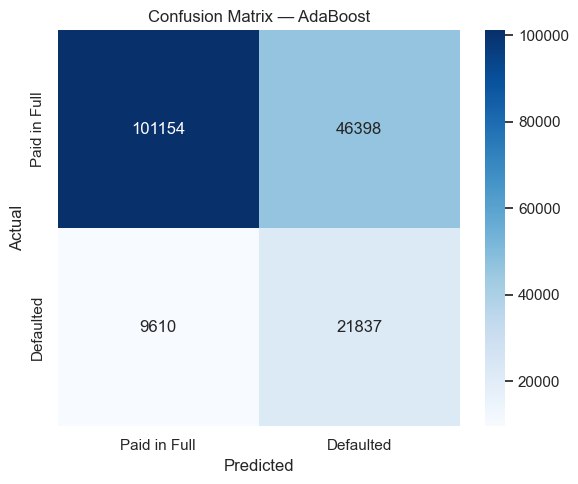

In [5]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Paid in Full", "Defaulted"],
            yticklabels=["Paid in Full", "Defaulted"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — AdaBoost")
plt.tight_layout()
plt.show()

# The bottom-left cell (false negatives) represents defaults the model missed.
# Minimising this cell is the primary business objective.

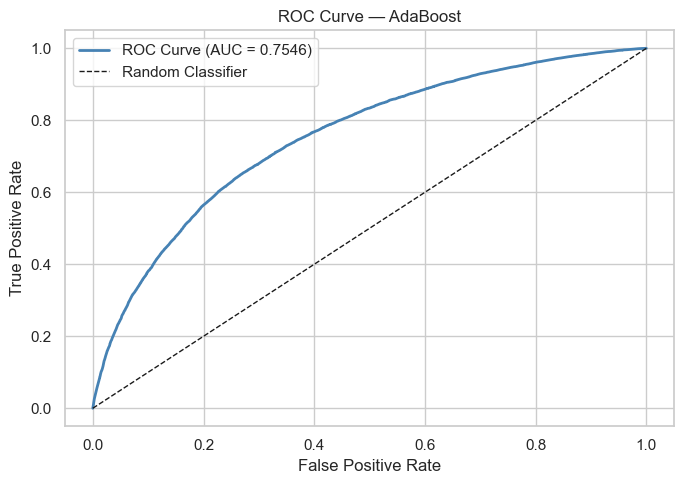

In [6]:
# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — AdaBoost")
ax.legend()
plt.tight_layout()
plt.show()

# A higher AUC means the model better separates defaults from non-defaults
# across all possible decision thresholds.

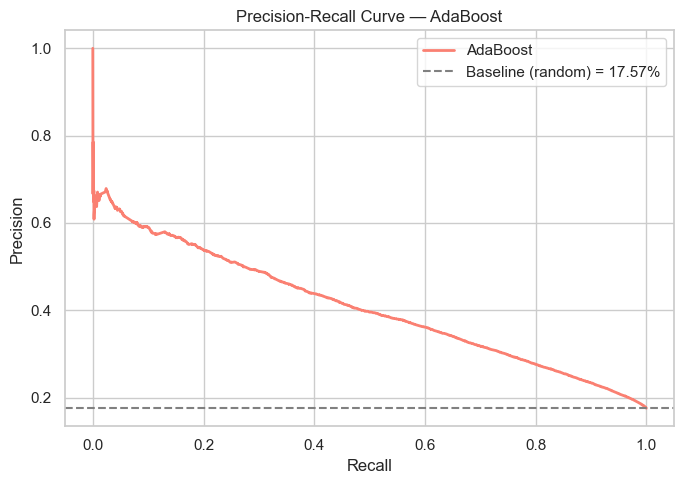

In [7]:
# ── Precision-Recall Curve ───────────────────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color="salmon", lw=2, label="AdaBoost")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           label=f"Baseline (random) = {y_test.mean():.2%}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — AdaBoost")
ax.legend()
plt.tight_layout()
plt.show()

# The dashed baseline represents a random classifier at the observed default rate.
# A good model keeps precision well above baseline at high recall values.

## 4. Feature Importance

AdaBoost aggregates feature importances from all its weak learner trees, weighting each tree's importance by its contribution to the ensemble (its `learning_rate`-scaled weight). Features used more often and at higher-impact splits across the boosting rounds receive higher importance scores.

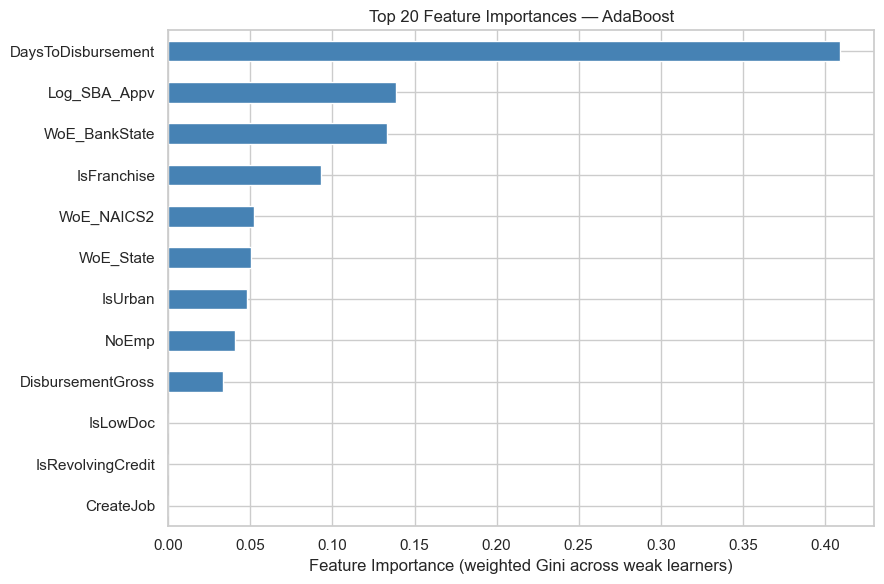

In [8]:
# ── Feature Importance bar chart ─────────────────────────────────────────────
# AdaBoost exposes feature_importances_ aggregated across all weak learners
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top_20.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Feature Importance (weighted Gini across weak learners)")
ax.set_title("Top 20 Feature Importances — AdaBoost")
plt.tight_layout()
plt.show()

# Features that most reliably distinguish defaults from non-defaults appear
# frequently as the splitting criterion in the ensemble's decision stumps.